In [32]:
import pandas as pd

In [33]:

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [34]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

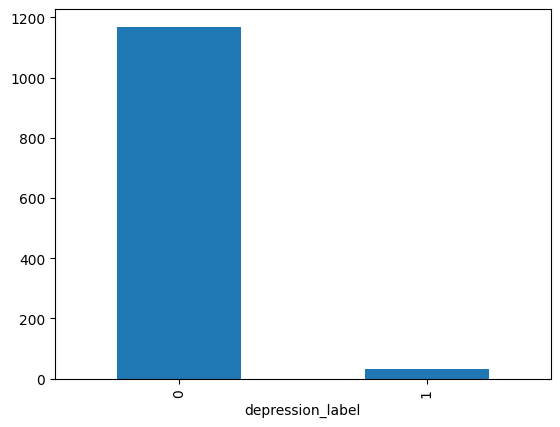

In [36]:
df['depression_label'].value_counts()
counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [37]:
X = df.drop(columns=['depression_label'])   # 拿掉答案那欄,剩下都是線索
y = df['depression_label']                  # 只挑「答案」那欄
X.shape, y.shape                             # 確認形狀

((1200, 12), (1200,))

In [38]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((960, 14), (240, 14))

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 只用 train 學 mean/std,再套用
X_test  = scaler.transform(X_test)        # 用 train 的 mean/std 套到 test

X_train.shape, X_test.shape

((960, 14), (240, 14))

In [41]:
# ============================================
# Logistic Regression + GridSearchCV
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

# 1. Define Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# 2. Define parameters for GridSearchCV
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# 4. Train model
grid_search.fit(X_train, y_train)

# 5. Best model
best_log_reg = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-validation F1 Score:")
print(grid_search.best_score_)

# 6. Predict
y_pred = best_log_reg.predict(X_test)
y_prob = best_log_reg.predict_proba(X_test)[:, 1]

# 7. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters:
{'C': 100, 'solver': 'liblinear'}
Best Cross-validation F1 Score:
0.4864646464646464
Accuracy: 0.9791666666666666
Precision: 0.5555555555555556
Recall: 0.8333333333333334
F1 Score: 0.6666666666666666
ROC-AUC: 0.9928774928774928

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       234
           1       0.56      0.83      0.67         6

    accuracy                           0.98       240
   macro avg       0.78      0.91      0.83       240
weighted avg       0.98      0.98      0.98       240


Confusion Matrix:
[[230   4]
 [  1   5]]


In [ ]:
# ============================================
# Using RFE for Feature Selection
# ============================================

from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

In [43]:
logreg = LogisticRegression(max_iter=5000)

In [44]:
feature_names = X.columns

rfe = RFE(
    estimator=logreg,
    n_features_to_select=5
)

rfe.fit(X_train, y_train)

selected_features = feature_names[rfe.support_]

print(selected_features)

Index(['daily_social_media_hours', 'sleep_hours', 'stress_level',
       'anxiety_level', 'gender_male'],
      dtype='str')


In [45]:
feature_ranking = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfe.ranking_
})

print(feature_ranking.sort_values(by='Ranking'))

                            Feature  Ranking
1          daily_social_media_hours        1
2                       sleep_hours        1
6                      stress_level        1
7                     anxiety_level        1
9                       gender_male        1
4              academic_performance        2
3          screen_time_before_sleep        3
10         platform_usage_Instagram        4
8                   addiction_level        5
5                 physical_activity        6
0                               age        7
12     social_interaction_level_low        8
13  social_interaction_level_medium        9
11            platform_usage_TikTok       10


In [46]:
X_train_selected = rfe.transform(X_train)
X_test_selected = rfe.transform(X_test)
model_selected = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

model_selected.fit(X_train_selected, y_train)

y_pred_selected = model_selected.predict(X_test_selected)

print("Accuracy after feature selection:")
print(accuracy_score(y_test, y_pred_selected))
f1_selected = f1_score(y_test, y_pred_selected)

print("F1 Score after feature selection:")
print(f1_selected)

Accuracy after feature selection:
0.9833333333333333
F1 Score after feature selection:
0.5


Recursive Feature Elimination (RFE) was used to automatically identify the most important features for Logistic Regression. The model recursively removed less important features and retained the top-performing subset of features. Performance was then re-evaluated using the selected feature set.

After applying RFE feature selection, the F1 score slightly decreased. This suggests that some removed features still contained useful predictive information. Logistic Regression already includes regularization, therefore aggressive feature elimination may reduce the model’s ability to capture important patterns in the dataset.

Then, I try to use another method to get a better F1 score by dropping the best combination of features

    Number of Features  F1 Score
0                   10  0.750000
1                    9  0.631579
2                   11  0.625000
3                   12  0.625000
4                   13  0.625000
5                   14  0.625000
6                    6  0.571429
7                    8  0.571429
8                    5  0.545455
9                    7  0.545455
10                   4  0.461538
11                   3  0.333333
12                   2  0.250000
13                   1  0.129870

Best Number of Features:
10

Best F1 Score:
0.75

Best Selected Features:
Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'academic_performance', 'stress_level', 'anxiety_level',
       'addiction_level', 'gender_male', 'platform_usage_Instagram',
       'social_interaction_level_medium'],
      dtype='str')

Removed Features:
Index(['screen_time_before_sleep', 'physical_activity',
       'platform_usage_TikTok', 'social_interaction_level_low'],
      dtype='str')


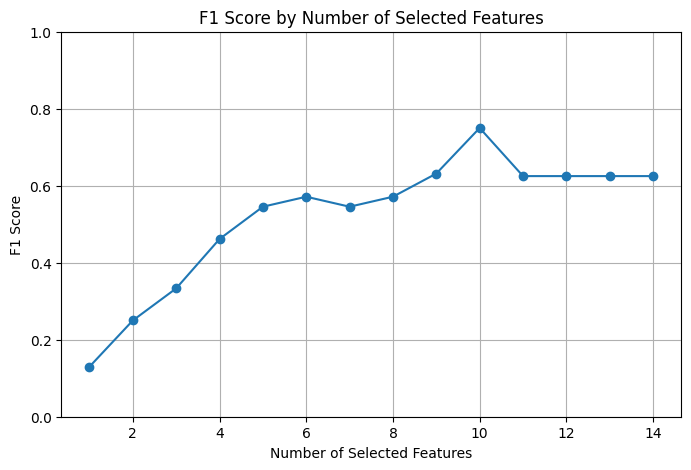

In [ ]:
# ============================================
# RFE with Different Number of Features
# ============================================
from sklearn.feature_selection import RFE
from sklearn.metrics import f1_score
import pandas as pd

results = []

best_f1 = 0
best_rfe = None
best_n = 0

for n in range(1, X_train.shape[1] + 1):
    
    rfe = RFE(
        estimator=LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ),
        n_features_to_select=n
    )
    
    rfe.fit(X_train, y_train)
    
    X_train_rfe = rfe.transform(X_train)
    X_test_rfe = rfe.transform(X_test)
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ))
    ])
    
    model.fit(X_train_rfe, y_train)
    
    y_pred_rfe = model.predict(X_test_rfe)
    
    current_f1 = f1_score(
        y_test,
        y_pred_rfe,
        zero_division=0
    )
    
    results.append({
        "Number of Features": n,
        "F1 Score": current_f1
    })
    

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_rfe = rfe
        best_n = n

rfe_results = pd.DataFrame(results)

print(
    rfe_results
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

print("\nBest Number of Features:")
print(best_n)

print("\nBest F1 Score:")
print(best_f1)

best_features = feature_names[best_rfe.support_]

print("\nBest Selected Features:")
print(best_features)

removed_features = feature_names[~best_rfe.support_]

print("\nRemoved Features:")
print(removed_features)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.plot(
    rfe_results["Number of Features"],
    rfe_results["F1 Score"],
    marker="o"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("F1 Score")
plt.title("F1 Score by Number of Selected Features")
plt.ylim(0, 1)
plt.grid(True)

plt.show()

The best F1 score was achieved when retaining 10 features. Removing too many features reduced model performance, suggesting that additional features still contributed useful predictive information.

In [ ]:
# ============================================
# Threshold Tuning with Precision-Recall Curve
# ============================================
from sklearn.feature_selection import RFE
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
import pandas as pd

y_prob = best_log_reg.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_index])

y_pred_threshold = (y_prob >= best_threshold).astype(int)

print("F1 after threshold tuning:")
print(f1_score(y_test, y_pred_threshold))

print(classification_report(y_test, y_pred_threshold, zero_division=0))
print(confusion_matrix(y_test, y_pred_threshold))

Best threshold: 0.9756737293308768
Best F1: 0.799999999952


          Experiment  F1 Score
0       GridSearchCV  0.666667
1     RFE 5 Features  0.500000
2  Best RFE Features  0.750000
3   Threshold Tuning  0.800000


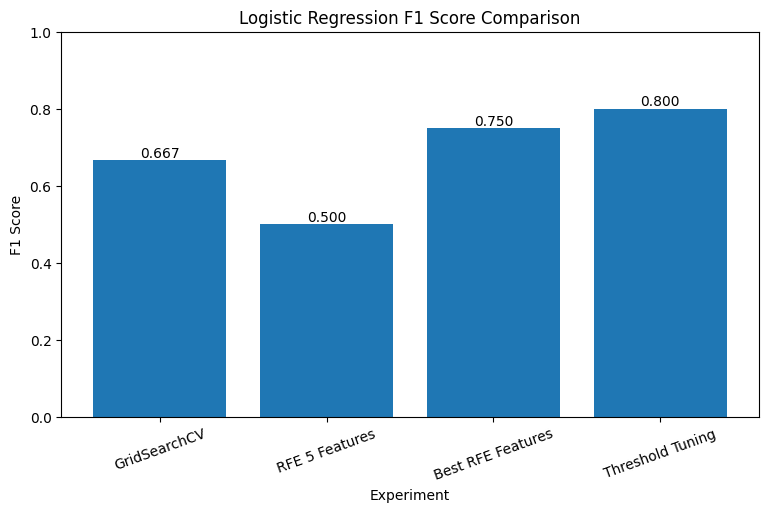

In [53]:


# F1 from GridSearchCV best Logistic Regression on test set
f1_gridsearch = f1_score(y_test, y_pred, zero_division=0)

# F1 from fixed 5-feature RFE
f1_rfe_5 = f1_selected

# Best F1 from trying different number of features
f1_best_rfe = best_f1

# F1 after threshold tuning
f1_threshold = f1_score(y_test, y_pred_threshold, zero_division=0)

f1_comparison = pd.DataFrame({
    "Experiment": [
        "GridSearchCV",
        "RFE 5 Features",
        "Best RFE Features",
        "Threshold Tuning"
    ],
    "F1 Score": [
        f1_gridsearch,
        f1_rfe_5,
        f1_best_rfe,
        f1_threshold
    ]
})

print(f1_comparison)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    f1_comparison["Experiment"],
    f1_comparison["F1 Score"]
)

plt.xlabel("Experiment")
plt.ylabel("F1 Score")
plt.title("Logistic Regression F1 Score Comparison")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20)
plt.show()

          Experiment  F1 Score
0       GridSearchCV  0.666667
1     RFE 5 Features  0.500000
2  Best RFE Features  0.750000
3   Threshold Tuning  0.800000


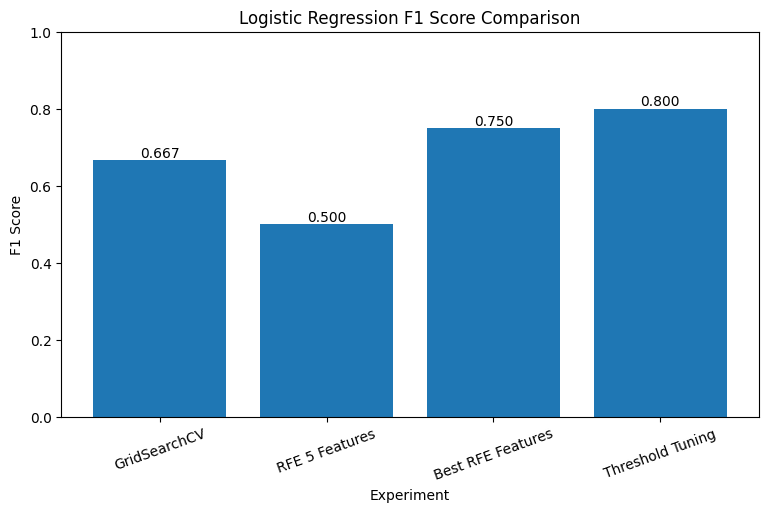

In [54]:


# F1 from GridSearchCV best Logistic Regression on test set
f1_gridsearch = f1_score(y_test, y_pred, zero_division=0)

# F1 from fixed 5-feature RFE
f1_rfe_5 = f1_selected

# Best F1 from trying different number of features
f1_best_rfe = best_f1

# F1 after threshold tuning
f1_threshold = f1_score(y_test, y_pred_threshold, zero_division=0)

f1_comparison = pd.DataFrame({
    "Experiment": [
        "GridSearchCV",
        "RFE 5 Features",
        "Best RFE Features",
        "Threshold Tuning"
    ],
    "F1 Score": [
        f1_gridsearch,
        f1_rfe_5,
        f1_best_rfe,
        f1_threshold
    ]
})

print(f1_comparison)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    f1_comparison["Experiment"],
    f1_comparison["F1 Score"]
)

plt.xlabel("Experiment")
plt.ylabel("F1 Score")
plt.title("Logistic Regression F1 Score Comparison")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20)
plt.show()

In [ ]:
# ============================================
# 1. Use best RFE-selected features
X_train_best_rfe = best_rfe.transform(X_train)
X_test_best_rfe = best_rfe.transform(X_test)

# 2. Train Logistic Regression using selected features
model_best_rfe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

model_best_rfe.fit(X_train_best_rfe, y_train)

# 3. Get predicted probabilities
y_prob_best_rfe = model_best_rfe.predict_proba(X_test_best_rfe)[:, 1]

# 4. Threshold tuning
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_best_rfe)

f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores[:-1])
best_threshold_rfe = thresholds[best_index]

print("Best threshold after RFE:", best_threshold_rfe)
print("Best F1 after RFE + threshold tuning:", f1_scores[best_index])

# 5. Predict using best threshold
y_pred_best_rfe_threshold = (y_prob_best_rfe >= best_threshold_rfe).astype(int)

# 6. Evaluate
print("F1 after Best RFE + Threshold Tuning:")
print(f1_score(y_test, y_pred_best_rfe_threshold, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rfe_threshold, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rfe_threshold))

Best threshold after RFE: 0.9417987505785166
Best F1 after RFE + threshold tuning: 0.799999999952
F1 after Best RFE + Threshold Tuning:
0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240


Confusion Matrix:
[[234   0]
 [  2   4]]


The RFE-based feature selection process did not further increase the final F1 score compared to the full-feature model. However, the model maintained the same performance while using fewer features, suggesting that several original features were redundant or less informative. This indicates that feature reduction helped simplify the model without sacrificing predictive capability.